# Naive Bayes model using One-Hot Vectors with Unigram+Bigram

In [1]:
import pandas as pd
import random
import json
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score, auc
from sklearn.preprocessing import label_binarize
import time
from symspellpy import SymSpell, Verbosity
import re
import emoji
from wordsegment import load, segment

In [2]:
# Data Table
data = {
    "Category": [
        "Model Configuration", "Training Data Check", "Training Data Check", 
        "Training Data Check", "Training Data Check", "Training Data Check", 
        "Feature Engineering", "Feature Engineering", "Cross Validation", 
        "Testing Data Check", "Testing Data Check", "Testing Data Check", 
        "Testing Data Check", "Testing Data Check", "Next Steps", "Next Steps"
    ],
    "Metric/Detail": [
        "Model Type", "Train Time", "Confusion Matrix Built?", 
        "F1 Score for Positive", "F1 Score for Negative", "AUC plotted?", 
        "Categorical/Numerical Features Added?", "Name 2 Features Added?", 
        "Cross Validation Implemented?", "Confusion Matrix Built?", 
        "F1 Score for Positive", "F1 Score for Negative", "AUC plotted?", 
        "Accuracy", "2 Interesting Findings",""
    ],
    "Details": [
        "MultinomialNB", "0.0326 seconds", "Yes", 
        "0.88", "0.96", "Yes", 
        "3", "review_length, exclamation_count", 
        "Yes", "Yes", 
        "0.75", "0.9", "Yes", 
        "0.8205", "Incorporate Advanced Feature Engineering", "Try Alternative Models with Hyperparameter Tuning"
    ]
}

df = pd.DataFrame(data)
df

,Category,Metric/Detail,Details
0,Model Configuration,Model Type,MultinomialNB
1,Training Data Check,Train Time,0.0326 seconds
2,Training Data Check,Confusion Matrix Built?,Yes
3,Training Data Check,F1 Score for Positive,0.88
4,Training Data Check,F1 Score for Negative,0.96
5,Training Data Check,AUC plotted?,Yes
6,Feature Engineering,Categorical/Numerical Features Added?,3
7,Feature Engineering,Name 2 Features Added?,"review_length, exclamation_count"
8,Cross Validation,Cross Validation Implemented?,Yes
9,Testing Data Check,Confusion Matrix Built?,Yes


In [3]:
# Load JSON data from a file
file_path = 'yelp_academic_dataset_review.json'

# Number of random lines to select
sample_size = 10000
selected_lines = []

# Reservoir sampling for large files
with open(file_path, 'r', encoding='utf-8') as file:
    for i, line in enumerate(file):
        if i < sample_size:
            selected_lines.append(line)
        else:
            # Replace a random element in the reservoir with decreasing probability
            r = random.randint(0, i)
            if r < sample_size:
                selected_lines[r] = line

# Convert the selected lines to a DataFrame
data = [json.loads(line) for line in selected_lines]
df = pd.DataFrame(data)

In [4]:
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,4oJpgCFxdO7nMn0rNfkpPw,pxYCc1i5Tf9gKL1hkJ6B4Q,jJKvRg2tYr7qWP-VxdjCTQ,2.0,1,1,1,"Great crab cakes (gluten free, too)!! But the ...",2015-06-29 03:59:34
1,ZCHXCX7z9dsmVstwSxQezQ,jUFJ3LZlBDesUVF3nxk7vQ,NfyMmdhkwSPjhFrckLbj-w,2.0,0,0,0,This isn't a restaurant that happens to be in ...,2017-09-12 01:48:48
2,seR4-Cc3tF7wl45uWNF-2g,nqitqUpkc5XnX5FqjRH_KQ,4YoVUmkpUBNtdYa804Wzvg,1.0,1,0,0,From out of town. Very interested in craft coc...,2015-03-30 05:51:56
3,S3BVV6luG93__wLcoXW_Ug,0obiKvJYXmFVTzLlp4o_RA,5FZWwOwiq1d04O5-oENxng,1.0,5,0,0,Really liked your old location SO much better....,2015-01-15 01:34:41
4,oK_EpP6EjTMY9Na7nz1H8Q,LdwgRGGGBUUbKgVAJRcgOA,0Sa2hQnbS9hoRthHKOGepg,3.0,1,0,0,The women in the salon were very sweet and I w...,2020-02-13 14:58:41


In [5]:
dfsimple = df[['stars', 'text']]

In [6]:
dfsimple.head()

,stars,text
0,2.0,"Great crab cakes (gluten free, too)!! But the ..."
1,2.0,This isn't a restaurant that happens to be in ...
2,1.0,From out of town. Very interested in craft coc...
3,1.0,Really liked your old location SO much better....
4,3.0,The women in the salon were very sweet and I w...


In [7]:
dfsimple.isnull().sum()

stars    0
text     0
dtype: int64

### Data cleaning

In [8]:
dfsimple['stars'] = dfsimple['stars'].astype(int)

C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\1282318873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsimple['stars'] = dfsimple['stars'].astype(int)


In [9]:
def map_sentiment(stars):
    if stars >= 4:
        return "Positive"
    elif stars == 3:
        return "Neutral"
    else:
        return "Negative"

dfsimple['sentiment'] = dfsimple['stars'].apply(map_sentiment)

C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\1913338171.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsimple['sentiment'] = dfsimple['stars'].apply(map_sentiment)


In [10]:
star_counts = dfsimple['stars'].value_counts().sort_index() 
star_counts

stars
1    1489
2     747
3    1016
4    2043
5    4705
Name: count, dtype: int64

In [11]:
sentcounts = dfsimple['sentiment'].value_counts().sort_index()  
sentcounts

sentiment
Negative    2236
Neutral     1016
Positive    6748
Name: count, dtype: int64

In [12]:
slang_dict = {
    "idk": "I do not know",
    "omg": "oh my god",
    "brb": "be right back",
    "ttyl": "talk to you later",
    "btw": "by the way",
    "lol": "laughing out loud",
    "thx": "thanks",
    "luv": "love",
    "gr8": "great",
    "b4": "before",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "dope": "amazing",
    "meh": "indifferent",
    "lit": "amazing",
    "awsm": "awesome",
    "rly": "really",
    "pls": "please",
    "tho": "though",
    "tbh": "to be honest",
    "h8": "hate",
    "ppl": "people",
    "bae": "before anyone else (significant other)",
    "yolo": "you only live once",
    "ftw": "for the win",
}
idioms_dict = {
    "a piece of cake": "very easy",
    "break the ice": "start a conversation",
    "hit the nail on the head": "do something perfectly",
    "burning a hole in my pocket": "spending too much money",
    "all ears": "listening attentively",
    "at the drop of a hat": "immediately",
    "costs an arm and a leg": "very expensive",
    "food for thought": "something to think about",
    "raining cats and dogs": "raining heavily",
    "under the weather": "feeling sick",
    "cut corners": "do something poorly to save time or money",
    "in a nutshell": "in summary",
    "on cloud nine": "extremely happy",
    "the icing on the cake": "an additional benefit",
}

### Data Preprocessing

In [13]:
load()
# Initialize SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# Load the dictionary file (pretrained SymSpell dictionary)
dictionary_path = "frequency_dictionary_en_82_765.txt"
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

# Preprocessing Function
def preprocess_text(text):
    # Step 1: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text, flags=re.MULTILINE)
    
    # Step 2: Handle mentions and hashtags
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Handle hashtags
    text = re.sub(r'#(\w+)', lambda m: ' '.join(segment(m.group(1))), text)
    
    # Step 3: Replace emojis with descriptions
    text = emoji.demojize(text)  
    text = text.replace(":", " ").replace("_", " ")  # Clean up emoji descriptions
    
    # Step 4: Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    
    # Step 5: Normalize text (convert to lowercase)
    text = text.lower()
    
    # Step 6: Expand slang terms
    for slang, expanded in slang_dict.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', expanded, text)
    
    # Step 7: Expand idioms
    for idiom, expanded in idioms_dict.items():
        text = text.replace(idiom, expanded)
    
    # Step 9: Spell correction using SymSpell
    words = text.split()
    corrected_words = []
    for word in words:
        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        if suggestions:
            corrected_words.append(suggestions[0].term)
        else:
            corrected_words.append(word)
    text = ' '.join(corrected_words)
    
    return text

# Apply the preprocessing to the text column
dfsimple['cleaned_text'] = dfsimple['text'].apply(preprocess_text)

C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\2269380379.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsimple['cleaned_text'] = dfsimple['text'].apply(preprocess_text)


In [14]:
def evaluate_multiclass_model(model, X_test, y_test):
    """
    Evaluate a multiclass classification model, including metrics, confusion matrix, and AUC visualization.

    Args:
        model: Trained classification model.
        X_test: Test feature data.
        y_test: Test target labels.
        class_names: List of class names in the same order as their numeric labels.
    """
    # Get predictions and predicted probabilities
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    class_names = ["Positive", "Neutral", "Negative"]


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    print("\nConfusion Matrix:\n", cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None, labels=class_names)
    recall = recall_score(y_test, y_pred, average=None, labels=class_names)
    f1 = f1_score(y_test, y_pred, average=None, labels=class_names)

    print(f"\nAccuracy: {accuracy:.4f}")
    print("\nPerformance per class:")
    for i, class_name in enumerate(class_names):
        print(f"{class_name} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-Score: {f1[i]:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

    # Compute AUC for each class
    auc_per_class = roc_auc_score(y_test, y_pred_proba, average=None, multi_class="ovr")
    macro_auc = roc_auc_score(y_test, y_pred_proba, average="macro", multi_class="ovr")

    # Print AUC
    print("\nAUC per class:")
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {auc_per_class[i]:.4f}")
    print(f"\nMacro AUC: {macro_auc:.4f}")

    y_test_dummies = pd.get_dummies(y_test, drop_first=False).values
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(y_test_dummies[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves for each class with appropriate class names
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic')
    
    for i in range(3):
        ax.plot(fpr[i], tpr[i], label=f'ROC curve (AUC = {roc_auc[i]:.2f}) for {class_names[i]}')

    ax.legend(loc="best")
    ax.grid(alpha=.4)
    sns.despine()
    plt.show()

    return {
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc_per_class": auc_per_class,
        "macro_auc": macro_auc,
    }


In [15]:
dfsimple.head()

,stars,text,sentiment,cleaned_text
0,2,"Great crab cakes (gluten free, too)!! But the ...",Negative,great crab cakes gluten free too but the eveni...
1,2,This isn't a restaurant that happens to be in ...,Negative,this int a restaurant that happens to be in a ...
2,1,From out of town. Very interested in craft coc...,Negative,from out of town very interested in craft cock...
3,1,Really liked your old location SO much better....,Negative,really liked your old location so much better ...
4,3,The women in the salon were very sweet and I w...,Neutral,the women in the salon were very sweet and i w...


## Model Building

In [16]:
y = dfsimple['sentiment']
X = dfsimple['cleaned_text']
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
vectorizer = CountVectorizer(ngram_range=(1, 2),  stop_words= 'english', binary = True, max_features=20000)  # Unigrams and Bigrams
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)
print(X_train.toarray().shape)

(8000, 20000)


In [18]:
print(y_train)

9254    Positive
1561    Positive
1670    Positive
6087    Positive
6669    Positive
          ...   
5734    Positive
5191    Negative
5390    Negative
860     Positive
7270    Positive
Name: sentiment, Length: 8000, dtype: object


In [19]:
start_time = time.time()

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

end_time = time.time()
train_time = end_time - start_time
print(f"Training Time: {train_time} seconds")

Training Time: 0.033998727798461914 seconds


In [20]:
print(y_pred.shape)

(2000,)


In [21]:
print(y_test.shape)

(2000,)


### Training Results


Confusion Matrix:
 [[5161   37  193]
 [ 136  604   78]
 [  97   62 1632]]


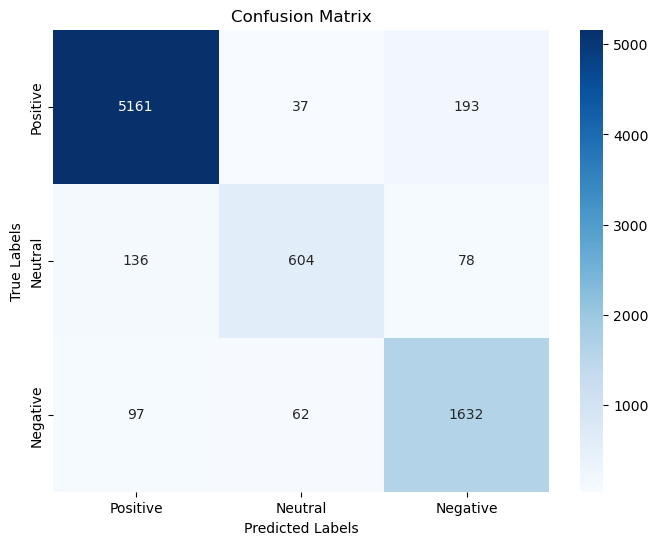


Accuracy: 0.9246

Performance per class:
Positive - Precision: 0.9568, Recall: 0.9573, F1-Score: 0.9571
Neutral - Precision: 0.8592, Recall: 0.7384, F1-Score: 0.7942
Negative - Precision: 0.8576, Recall: 0.9112, F1-Score: 0.8836

Classification Report:
               precision    recall  f1-score   support

    Positive       0.86      0.91      0.88      1791
     Neutral       0.86      0.74      0.79       818
    Negative       0.96      0.96      0.96      5391

    accuracy                           0.92      8000
   macro avg       0.89      0.87      0.88      8000
weighted avg       0.92      0.92      0.92      8000


AUC per class:
Positive: 0.9831
Neutral: 0.9708
Negative: 0.9839

Macro AUC: 0.9793


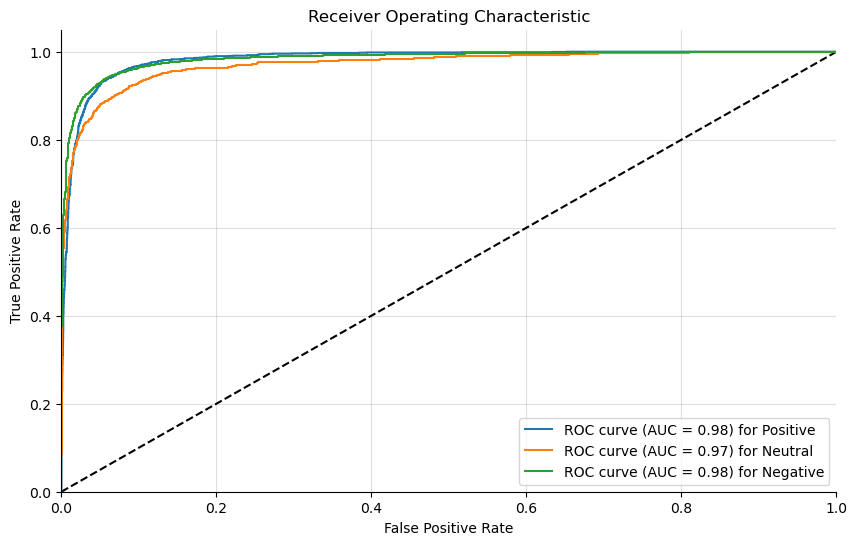

In [22]:
results = evaluate_multiclass_model(nb, X_train, y_train)

### Testing Results


Confusion Matrix:
 [[1271   13   73]
 [ 108   27   63]
 [  46   34  365]]


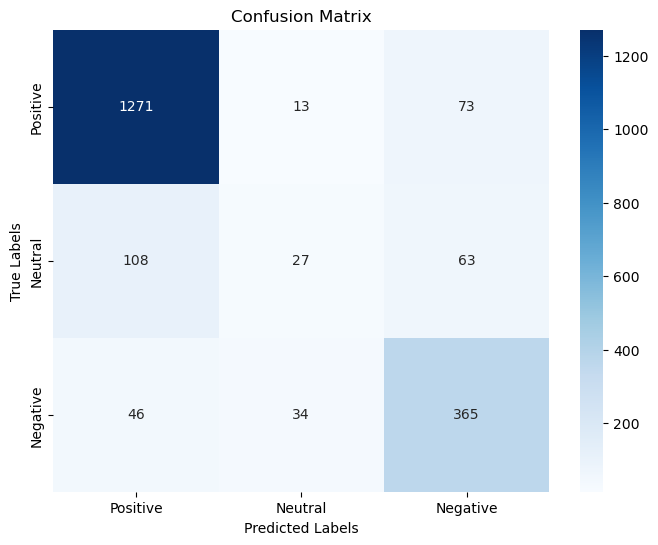


Accuracy: 0.8315

Performance per class:
Positive - Precision: 0.8919, Recall: 0.9366, F1-Score: 0.9137
Neutral - Precision: 0.3649, Recall: 0.1364, F1-Score: 0.1985
Negative - Precision: 0.7285, Recall: 0.8202, F1-Score: 0.7717

Classification Report:
               precision    recall  f1-score   support

    Positive       0.73      0.82      0.77       445
     Neutral       0.36      0.14      0.20       198
    Negative       0.89      0.94      0.91      1357

    accuracy                           0.83      2000
   macro avg       0.66      0.63      0.63      2000
weighted avg       0.80      0.83      0.81      2000


AUC per class:
Positive: 0.9327
Neutral: 0.7413
Negative: 0.9297

Macro AUC: 0.8679


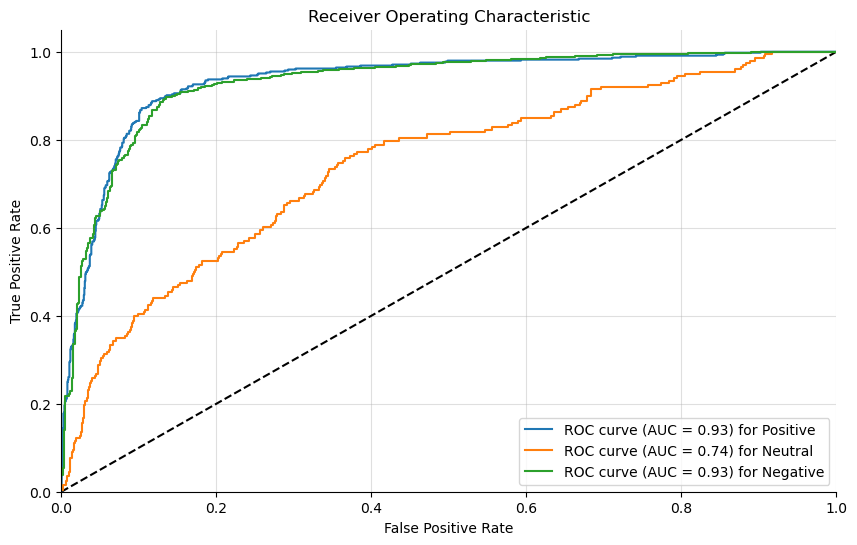

In [23]:
results = evaluate_multiclass_model(nb, X_test, y_test)

## Trying out eqaully divided data to fix class imbalance

In [24]:
import random
import json
import pandas as pd

# Define file path and sample size
file_path = 'yelp_academic_dataset_review.json' 
sample_size_per_category = 3500

# Initialize reservoirs for each category
reservoir_low = []  # For 1-2 stars
reservoir_mid = []  # For 3 stars
reservoir_high = []  # For 4-5 stars

# Reservoir sampling for large files
with open(file_path, 'r', encoding='utf-8') as file:
    for i, line in enumerate(file):
        # Parse the JSON line
        record = json.loads(line)
        stars = int(record.get('stars', 0))  # Ensure 'stars' is an integer

        # Assign the line to the appropriate category
        if stars in [1, 2]:
            reservoir = reservoir_low
        elif stars == 3:
            reservoir = reservoir_mid
        elif stars in [4, 5]:
            reservoir = reservoir_high
        else:
            continue  # Skip if stars are not in the expected range

        # Perform reservoir sampling for the current category
        if len(reservoir) < sample_size_per_category:
            reservoir.append(record)
        else:
            r = random.randint(0, i)
            if r < sample_size_per_category:
                reservoir[r] = record

# Combine the selected lines into a single dataset
selected_data = reservoir_low + reservoir_mid + reservoir_high
random.shuffle(selected_data)  # Shuffle to mix different categories

# Convert the selected data to a DataFrame
df2 = pd.DataFrame(selected_data)

# Display the counts of each star rating in the sampled data
print("Sampled data star counts:")
print(df2['stars'].value_counts())

Sampled data star counts:
stars
3.0    3500
5.0    2398
1.0    2212
2.0    1288
4.0    1102
Name: count, dtype: int64


In [25]:
def map_sentiment(stars):
    if stars >= 4:
        return "Positive"
    elif stars == 3:
        return "Neutral"
    else:
        return "Negative"

df2['sentiment'] = df2['stars'].apply(map_sentiment)

df2['cleaned_text'] = df2['text'].apply(preprocess_text)
yblc = df2['sentiment']
Xblc = df2['cleaned_text']
# Split the dataset into training and testing
X_trainblc, X_testblc, y_trainblc, y_testblc = train_test_split(Xblc, yblc, test_size=0.2, random_state=42)
vectorizer = CountVectorizer(ngram_range=(1, 2),  stop_words= 'english',binary = True, max_features=20000)  # Unigrams and Bigrams
X_trainblc = vectorizer.fit_transform(X_trainblc)
X_testblc = vectorizer.transform(X_testblc)
print(X_trainblc.toarray().shape)
nb2 = MultinomialNB()

# Train the model
start_time = time.time()
nb2.fit(X_trainblc, y_trainblc)
y_predblc = nb2.predict(X_testblc)
end_time = time.time()
train_time = end_time - start_time
print(f"Training Time: {train_time} seconds")

(8400, 20000)
Training Time: 0.02346658706665039 seconds


### Training Results


Confusion Matrix:
 [[2516  152   84]
 [ 163 2422  249]
 [  61  428 2325]]


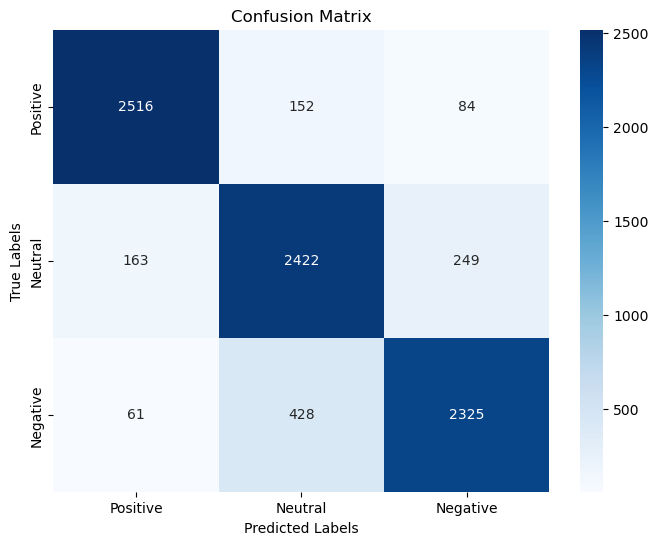


Accuracy: 0.8646

Performance per class:
Positive - Precision: 0.9182, Recall: 0.9142, F1-Score: 0.9162
Neutral - Precision: 0.8068, Recall: 0.8546, F1-Score: 0.8300
Negative - Precision: 0.8747, Recall: 0.8262, F1-Score: 0.8498

Classification Report:
               precision    recall  f1-score   support

    Positive       0.87      0.83      0.85      2814
     Neutral       0.81      0.85      0.83      2834
    Negative       0.92      0.91      0.92      2752

    accuracy                           0.86      8400
   macro avg       0.87      0.87      0.87      8400
weighted avg       0.87      0.86      0.86      8400


AUC per class:
Positive: 0.9580
Neutral: 0.9416
Negative: 0.9832

Macro AUC: 0.9609


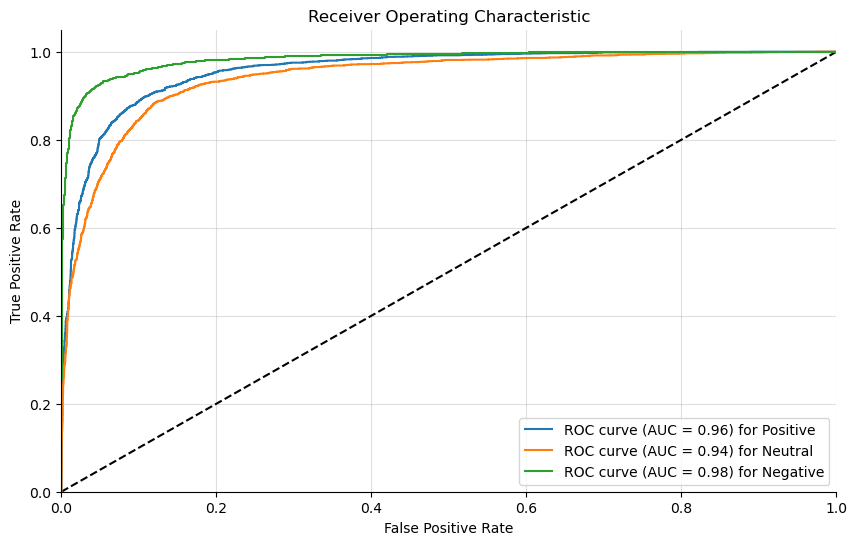

In [26]:
results = evaluate_multiclass_model(nb2, X_trainblc, y_trainblc)

### Testing Results


Confusion Matrix:
 [[560 138  50]
 [108 452 106]
 [ 13 184 489]]


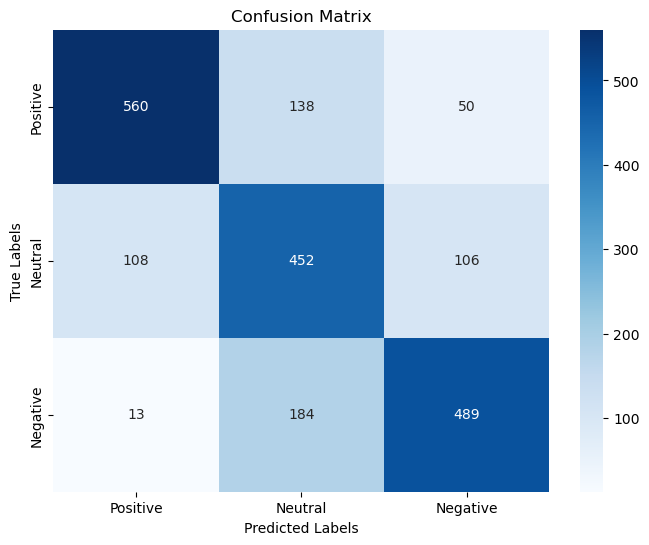


Accuracy: 0.7148

Performance per class:
Positive - Precision: 0.8223, Recall: 0.7487, F1-Score: 0.7838
Neutral - Precision: 0.5840, Recall: 0.6787, F1-Score: 0.6278
Negative - Precision: 0.7581, Recall: 0.7128, F1-Score: 0.7348

Classification Report:
               precision    recall  f1-score   support

    Positive       0.76      0.71      0.73       686
     Neutral       0.58      0.68      0.63       666
    Negative       0.82      0.75      0.78       748

    accuracy                           0.71      2100
   macro avg       0.72      0.71      0.72      2100
weighted avg       0.73      0.71      0.72      2100


AUC per class:
Positive: 0.8767
Neutral: 0.7937
Negative: 0.9120

Macro AUC: 0.8608


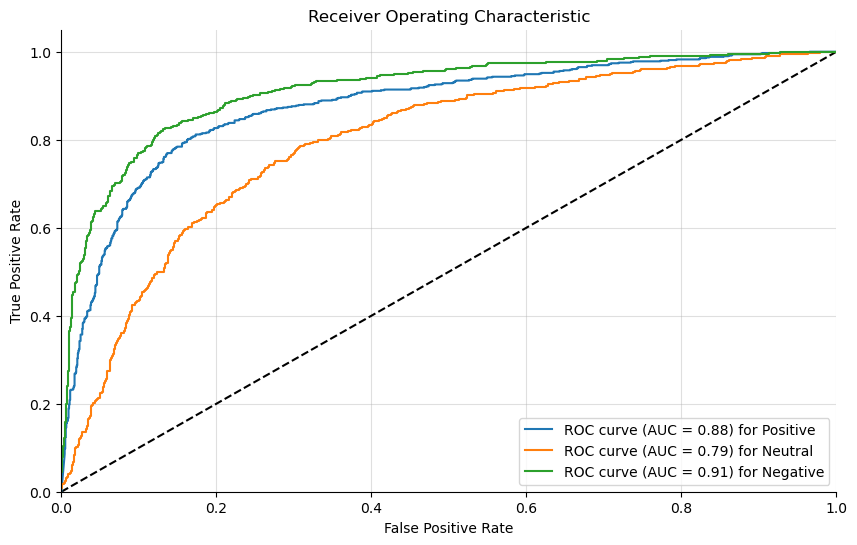

In [27]:
results = evaluate_multiclass_model(nb2, X_testblc, y_testblc)

However, Through this we can see class imbalance doesn't play a big factor in this instance.
Therefore, we will continue with the first dataset.

As we have the data, model and preprocessing figured out, We can move ahead with tuning the model with new features and cross validation

## Feature Engineering

In the iteration of the model, we removed the '!' and '?' to make it easier training, but in reality punctuation plays a huge role in determining sentiment.
Therefore, We can create the following features to see if the model does any better with additional infomation.

In [28]:
# Add new features to the dataset
dfsimple["review_length"] = dfsimple["text"].apply(lambda x: len(x.split()))  # Word count
dfsimple["exclamation_count"] = dfsimple["text"].apply(lambda x: x.count("!"))
dfsimple["question_count"] = dfsimple["text"].apply(lambda x: x.count("?"))

C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\2863523588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsimple["review_length"] = dfsimple["text"].apply(lambda x: len(x.split()))  # Word count
C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\2863523588.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsimple["exclamation_count"] = dfsimple["text"].apply(lambda x: x.count("!"))
C:\Users\sarak\AppData\Local\Temp\ipykernel_3268\2863523588.py:4: SettingWithCopyWarning: 
A value is trying to be set

In [29]:
dfsimple.head()

,stars,text,sentiment,cleaned_text,review_length,exclamation_count,question_count
0,2,"Great crab cakes (gluten free, too)!! But the ...",Negative,great crab cakes gluten free too but the eveni...,199,3,4
1,2,This isn't a restaurant that happens to be in ...,Negative,this int a restaurant that happens to be in a ...,28,1,0
2,1,From out of town. Very interested in craft coc...,Negative,from out of town very interested in craft cock...,204,0,1
3,1,Really liked your old location SO much better....,Negative,really liked your old location so much better ...,41,0,0
4,3,The women in the salon were very sweet and I w...,Neutral,the women in the salon were very sweet and i w...,113,0,0


In [30]:
y = dfsimple['sentiment']
X = dfsimple[ 'cleaned_text']
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
vectorizer = CountVectorizer(ngram_range=(1, 2),  stop_words= 'english', binary = True, max_features=20000)  # Unigrams and Bigrams
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)
print(X_train.toarray().shape)
start_time = time.time()

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

end_time = time.time()
train_time = end_time - start_time
print(f"Training Time: {train_time} seconds")

(8000, 20000)
Training Time: 0.026999950408935547 seconds


### Training Results


Confusion Matrix:
 [[5161   37  193]
 [ 136  604   78]
 [  97   62 1632]]


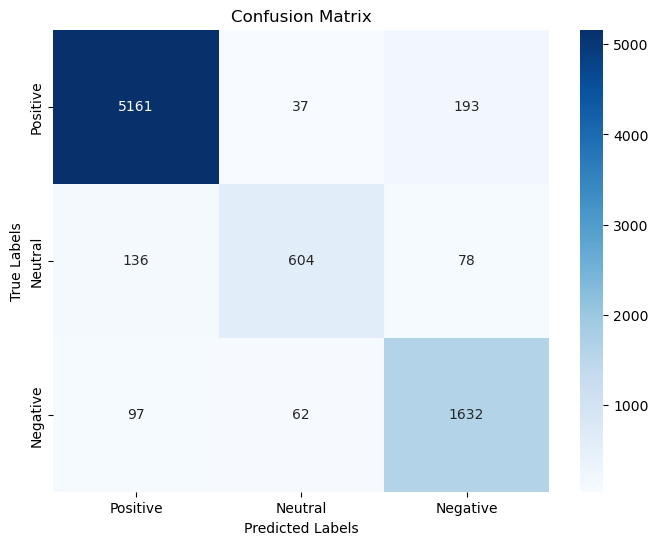


Accuracy: 0.9246

Performance per class:
Positive - Precision: 0.9568, Recall: 0.9573, F1-Score: 0.9571
Neutral - Precision: 0.8592, Recall: 0.7384, F1-Score: 0.7942
Negative - Precision: 0.8576, Recall: 0.9112, F1-Score: 0.8836

Classification Report:
               precision    recall  f1-score   support

    Positive       0.86      0.91      0.88      1791
     Neutral       0.86      0.74      0.79       818
    Negative       0.96      0.96      0.96      5391

    accuracy                           0.92      8000
   macro avg       0.89      0.87      0.88      8000
weighted avg       0.92      0.92      0.92      8000


AUC per class:
Positive: 0.9831
Neutral: 0.9708
Negative: 0.9839

Macro AUC: 0.9793


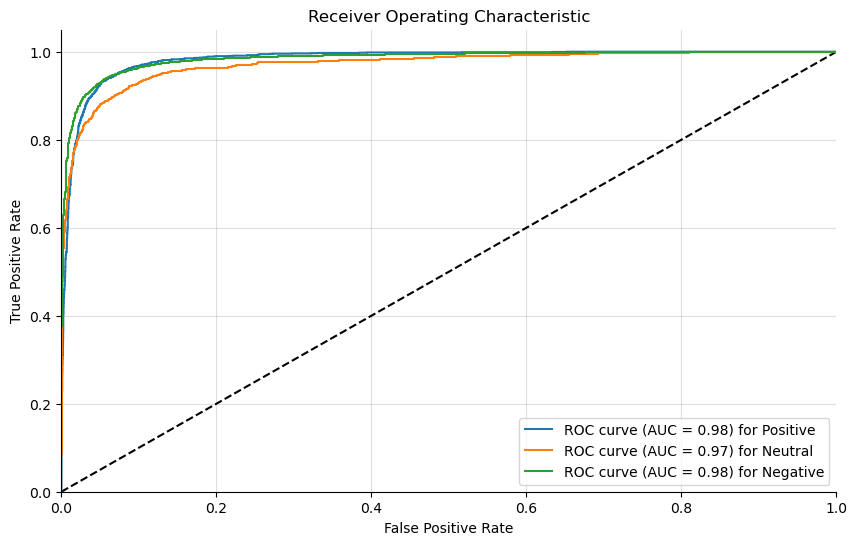

In [31]:
results = evaluate_multiclass_model(nb, X_train, y_train)

### Testing Results


Confusion Matrix:
 [[1271   13   73]
 [ 108   27   63]
 [  46   34  365]]


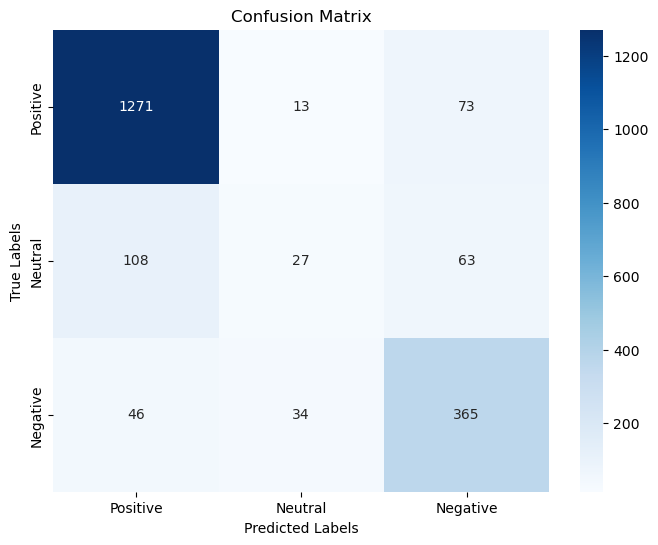


Accuracy: 0.8315

Performance per class:
Positive - Precision: 0.8919, Recall: 0.9366, F1-Score: 0.9137
Neutral - Precision: 0.3649, Recall: 0.1364, F1-Score: 0.1985
Negative - Precision: 0.7285, Recall: 0.8202, F1-Score: 0.7717

Classification Report:
               precision    recall  f1-score   support

    Positive       0.73      0.82      0.77       445
     Neutral       0.36      0.14      0.20       198
    Negative       0.89      0.94      0.91      1357

    accuracy                           0.83      2000
   macro avg       0.66      0.63      0.63      2000
weighted avg       0.80      0.83      0.81      2000


AUC per class:
Positive: 0.9327
Neutral: 0.7413
Negative: 0.9297

Macro AUC: 0.8679


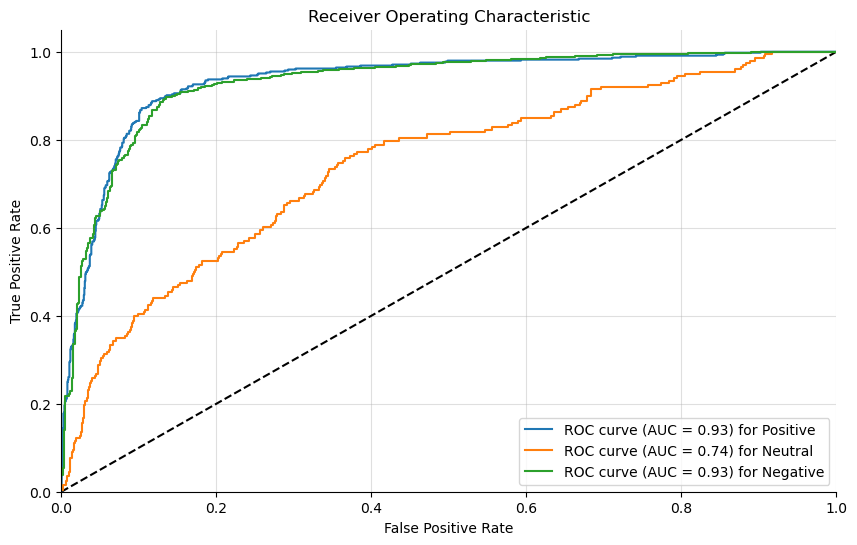

In [32]:
results = evaluate_multiclass_model(nb, X_test, y_test)

In [33]:
import numpy as np
import pandas as pd

# Extract feature names
feature_names = vectorizer.get_feature_names_out()

# Extract feature log probabilities for each class
class_labels = nb.classes_  # ['Negative', 'Neutral', 'Positive']
feature_importance = nb.feature_log_prob_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame(
    feature_importance.T, 
    index=feature_names, 
    columns=class_labels
)

# Calculate the absolute importance difference (optional)
feature_importance_df["importance_diff"] = (
    np.abs(feature_importance_df["Positive"] - feature_importance_df["Negative"])
)

# Sort features by importance difference (descending order)
sorted_features = feature_importance_df.sort_values(by="importance_diff", ascending=False)

# Display the top 10 most important features
print("Top 10 Important Features:")
print(sorted_features.head(10))

Top 10 Important Features:
                  Negative    Neutral   Positive  importance_diff
unprofessional   -8.100552  -9.959632 -12.438913         4.338361
rudely           -8.564857 -11.058244 -12.438913         3.874056
worst experience -8.611377 -10.365097 -12.438913         3.827536
terrible service -8.883311 -10.365097 -12.438913         3.555602
poor customer    -8.883311 -10.365097 -12.438913         3.555602
worst            -6.520101  -8.978802 -10.041018         3.520917
nasty            -8.254702  -9.959632 -11.745766         3.491064
refund           -7.894700  -9.448806 -11.340301         3.445601
just bad         -9.016842  -9.671949 -12.438913         3.422071
wont going       -9.016842  -9.959632 -12.438913         3.422071


In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Create a pipeline to handle vectorization and model together
pipeline = make_pipeline(CountVectorizer(ngram_range=(1, 2), stop_words='english', binary=True, max_features=20000), MultinomialNB())

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")  # 5-fold CV

# Display results
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores)}")

Cross-Validation Accuracy Scores: [0.8345 0.817  0.826  0.8345 0.825 ]
Mean CV Accuracy: 0.8274000000000001
